# Input attribution — what the analysts leaned on, and when that changed

Every view carries an `input_ranking`: **every** measurement the analyst was handed, each with
a `pull` (the direction it pushed **the view**, not the direction the input moved) and a
`weight` in 0-1 — including the ones it ignored, at weight 0.

That completeness requirement is what makes this an attribution rather than a citation list.
If a field only listed what got cited, an input missing from the list would be
indistinguishable from one never read. Requiring all of them turns "I ignored this" into an
observable.

Two questions live in the data, and a mean weight answers only the first:

| | question | read from |
|---|---|---|
| **WHICH** | which measurements carry the view | mean weight, share-top, share-ignored |
| **WHEN** | does that shift, and does the shift track anything | signed panel over time, concentration, pull flips |

The distinction is diagnostic. An analyst that always leans on one input is **rigid** and will
miss a regime change by construction. One that rotates is **responsive** — or chasing noise,
and which of those depends on whether the rotation lines up with something real. **Neither
shows up in an IC.**

`input_ranking` was added 2026-07-24, so this notebook could not have been written against any
earlier run. Offline, $0, and never allowed to inform a prompt (`docs/analyst-layer.md` §6).

In [1]:
import sys, os, glob, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath("..")); sys.path.insert(0, ".")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import _viz as V; V.use_style()
from src.layered.evaluation.runs import load_run
from src.layered.evaluation import attribution as A, ic_diagnostics as D

BOARD, ARM = "../reports/hk", "anon_cue"
ARMS = ["none", "anon_cue", "anon_full", "plain"]
runs = {}
for f in sorted(glob.glob(f"{BOARD}/*.jsonl")):
    st = os.path.basename(f)[:-6]
    for a in ARMS:
        if st.endswith("_" + a): runs[(st[:-(len(a)+1)], a)] = load_run(f); break
DRIVERS = sorted({d for d, _ in runs})

cov = pd.DataFrame([{"driver": d, "arm": a,
                     "ranked": len(A.weight_panel(runs[(d,a)])),
                     "n": len(runs[(d,a)].views)} for d in DRIVERS for a in ARMS])
cov["coverage"] = cov["ranked"] / cov["n"]
print(f"{len(runs)} legs. input_ranking present on "
      f"{cov['ranked'].sum()}/{cov['n'].sum()} views "
      f"({cov['ranked'].sum()/cov['n'].sum():.1%}).")
print("\nlowest-coverage legs (a thin leg makes every mean below it noisy):")
print(cov.nsmallest(5, "coverage")[["driver","arm","ranked","n","coverage"]].to_string(index=False))

44 legs. input_ranking present on 5474/5528 views (99.0%).

lowest-coverage legs (a thin leg makes every mean below it noisy):
         driver       arm  ranked   n  coverage
    curve_slope     plain     121 126  0.960317
 sector_breadth anon_full     122 126  0.968254
      inflation anon_full     121 124  0.975806
labor_tightness anon_full     121 124  0.975806
    curve_slope  anon_cue     123 126  0.976190


## 1 — WHICH: the two questions a mean weight conflates

Bars are **mean weight** — how heavily an input was leaned on across the whole run. Dots are
**share of meetings that input was the single heaviest** — how often it *led*.

These come apart, and the gap is the interesting part. A high bar with a low dot is a
**steady background consideration**, always in the mix and rarely decisive. A low bar with a
high dot is a **swing input**: usually irrelevant, occasionally the whole story. Ranking on
the bar alone hides the second kind entirely.

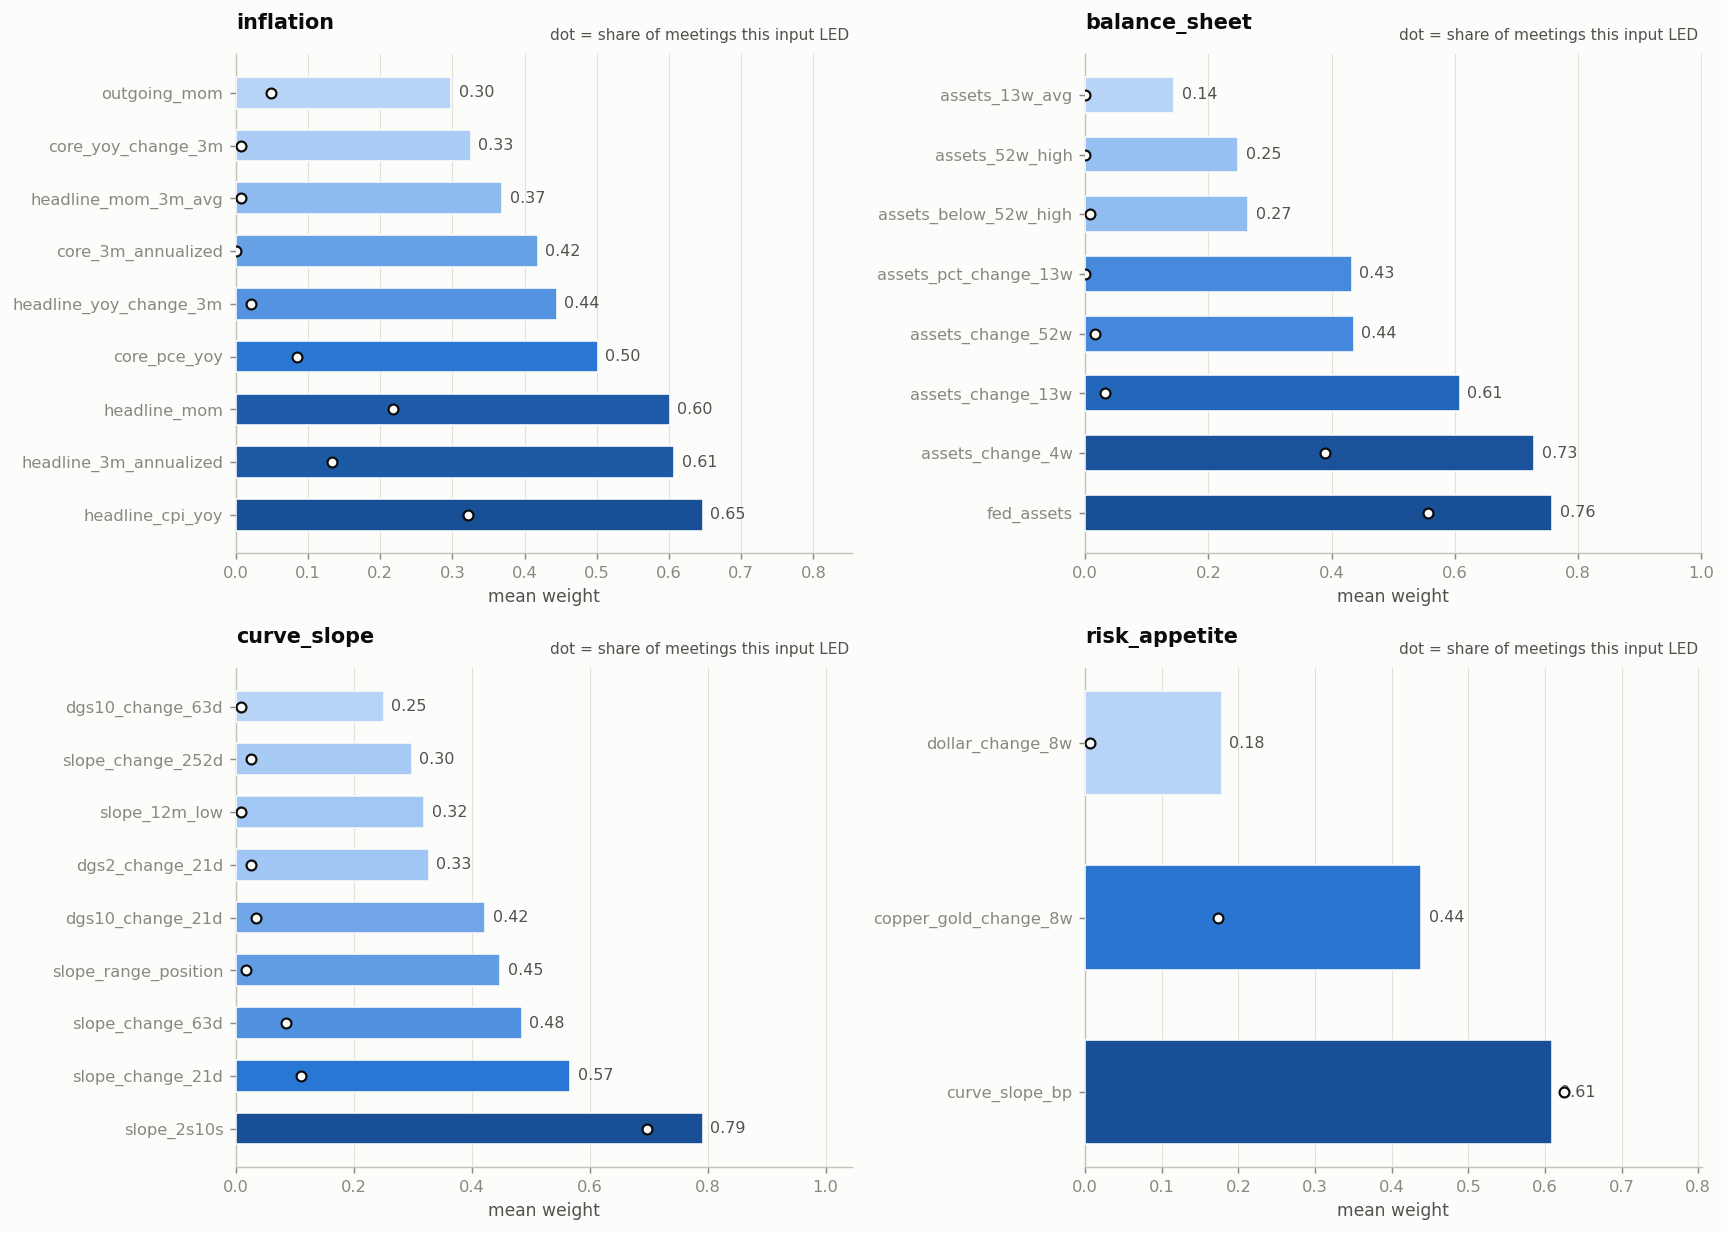

heaviest input == most-often-leading input on 10/11 analysts.
Where they differ, the two questions genuinely diverge:

              driver heaviest most_often_top  same
financial_conditions     nfci nfci_change_4w False


In [2]:
show = ["inflation", "balance_sheet", "curve_slope", "risk_appetite"]
fig, axes = plt.subplots(2, 2, figsize=(13.4, 9.6))
for ax, drv in zip(axes.ravel(), show):
    s = A.attention_summary(runs[(drv, ARM)]).head(9)
    V.ranked_bar(ax, s["input"], s["mean_weight"].values,
                 second=s["share_top"].values,
                 second_label="dot = share of meetings this input LED",
                 xlabel="mean weight")
    V.title(ax, drv)
plt.tight_layout(); plt.show()

gap = []
for d in DRIVERS:
    s = A.attention_summary(runs[(d, ARM)])
    if s.empty: continue
    s = s[s["share_ranked"] > .5]
    by_w, by_t = s.nlargest(1,"mean_weight"), s.nlargest(1,"share_top")
    if by_w.empty or by_t.empty: continue
    gap.append({"driver": d, "heaviest": by_w["input"].iloc[0],
                "most_often_top": by_t["input"].iloc[0],
                "same": by_w["input"].iloc[0] == by_t["input"].iloc[0]})
G = pd.DataFrame(gap)
print(f"heaviest input == most-often-leading input on {int(G['same'].sum())}/{len(G)} analysts.")
print("Where they differ, the two questions genuinely diverge:\n")
print(G[~G["same"]].to_string(index=False))

## 2 — Is anything actually set aside?

The weight-0 entries are the cheapest integrity check in the run. If an analyst never
assigned zero, the ranking would be a formality — a list padded to satisfy the schema. If it
zeroes almost everything, the mandate is too wide for the driver.

Ordered by share of ranked inputs at weight 0, one row per analyst, all four arms overlaid.

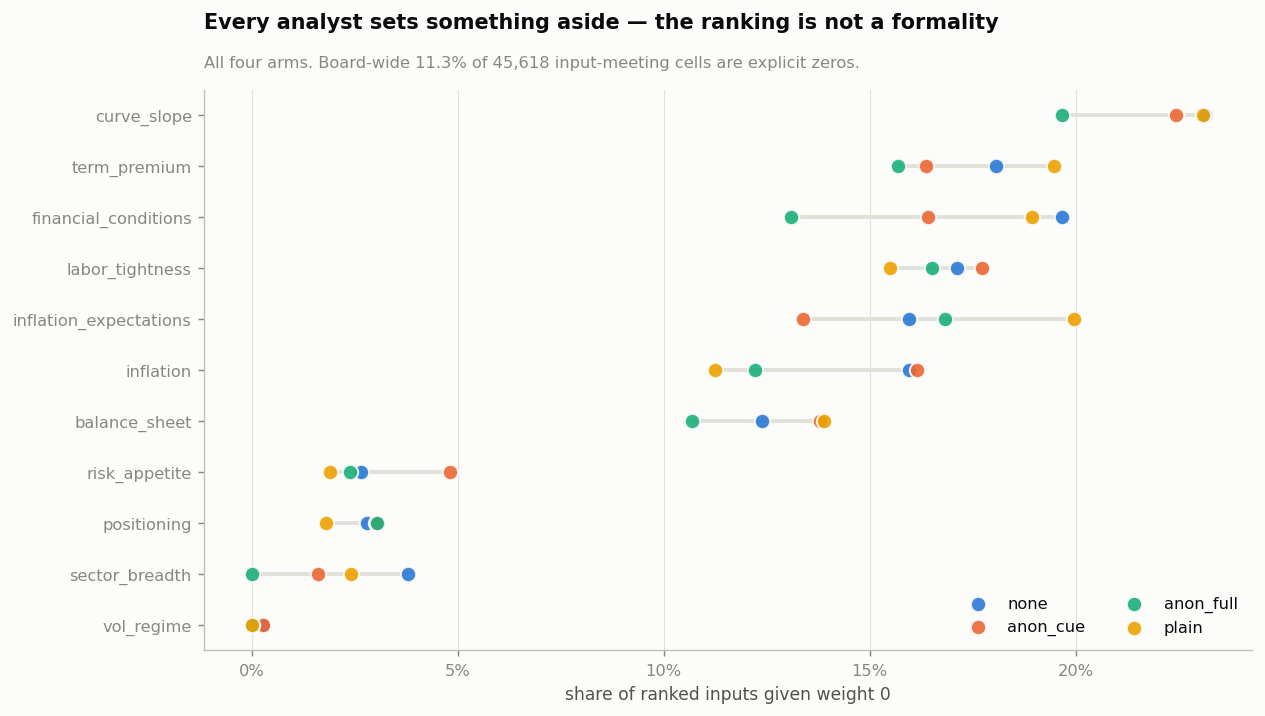

           share_zero  share_heavy  mean_w
arm                                       
anon_cue        0.115        0.365   0.366
anon_full       0.100        0.365   0.370
none            0.120        0.350   0.358
plain           0.117        0.345   0.355


In [3]:
rows = []
for d in DRIVERS:
    for a in ARMS:
        wp = A.weight_panel(runs[(d, a)])
        if wp.empty: continue
        v = wp.values[~np.isnan(wp.values)]
        rows.append({"driver": d, "arm": a, "n_cells": v.size,
                     "share_zero": float((v == 0).mean()),
                     "share_heavy": float((v >= .5).mean()),
                     "mean_w": float(v.mean()), "n_inputs": wp.shape[1]})
Z = pd.DataFrame(rows)
piv = Z.pivot_table(index="driver", columns="arm", values="share_zero")
order = piv.mean(axis=1).sort_values().index

fig, ax = plt.subplots(figsize=(10.4, 5.6))
y = np.arange(len(order))
for i, a in enumerate(ARMS):
    ax.scatter(piv.loc[order, a], y, s=72, color=V.CAT[i], label=a, zorder=4,
               edgecolor=V.SURFACE, linewidth=1.1, alpha=.9)
ax.hlines(y, piv.loc[order].min(axis=1), piv.loc[order].max(axis=1),
          color=V.GRID, lw=2.2, zorder=2)
ax.set_yticks(y); ax.set_yticklabels(order)
ax.xaxis.set_major_formatter(lambda v, p: f"{v:.0%}")
ax.set_xlabel("share of ranked inputs given weight 0")
ax.legend(loc="lower right", ncols=2)
V.title(ax, "Every analyst sets something aside — the ranking is not a formality",
        f"All four arms. Board-wide {Z['share_zero'].mean():.1%} of "
        f"{int(Z['n_cells'].sum()):,} input-meeting cells are explicit zeros.")
V.grid(ax, "x"); plt.show()
print(Z.groupby("arm")[["share_zero","share_heavy","mean_w"]].mean().round(3).to_string())

## 3 — WHEN: the signed attention panel

Rows are inputs, columns are **calendar quarters**, colour is `weight x sign(pull)` — so blue
is "this measurement argued the view up", red "argued it down", pale "was read and set aside".
Grey is an input not ranked that quarter.

**Quarterly, not monthly.** The monthly version of this panel is a candy-stripe: 126 columns of
a noisy series, where sign flips month to month swamp any structure. At quarterly resolution
`balance_sheet`'s QE→QT reversal is the most obvious thing on the page. That is not smoothing
for looks — the underlying regime changed on a quarterly, not monthly, cadence.

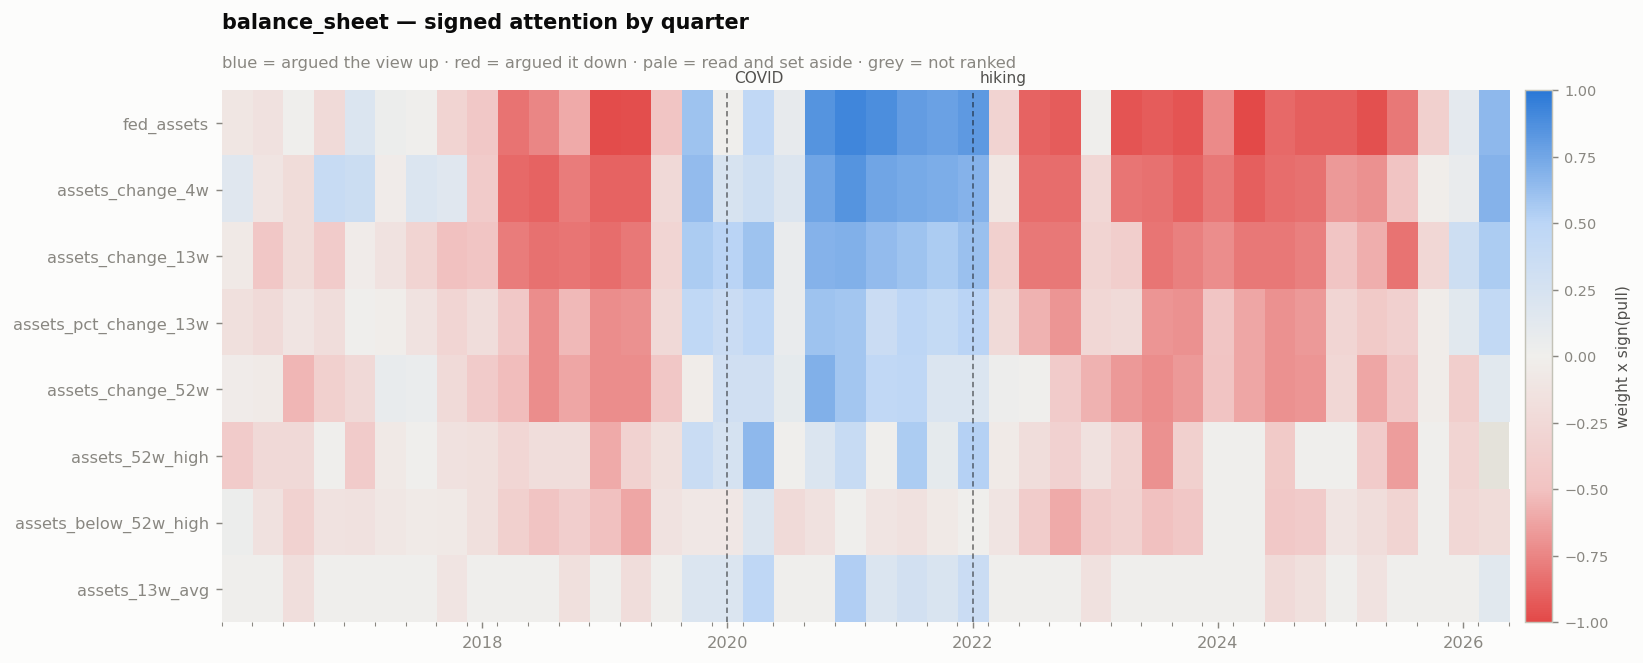

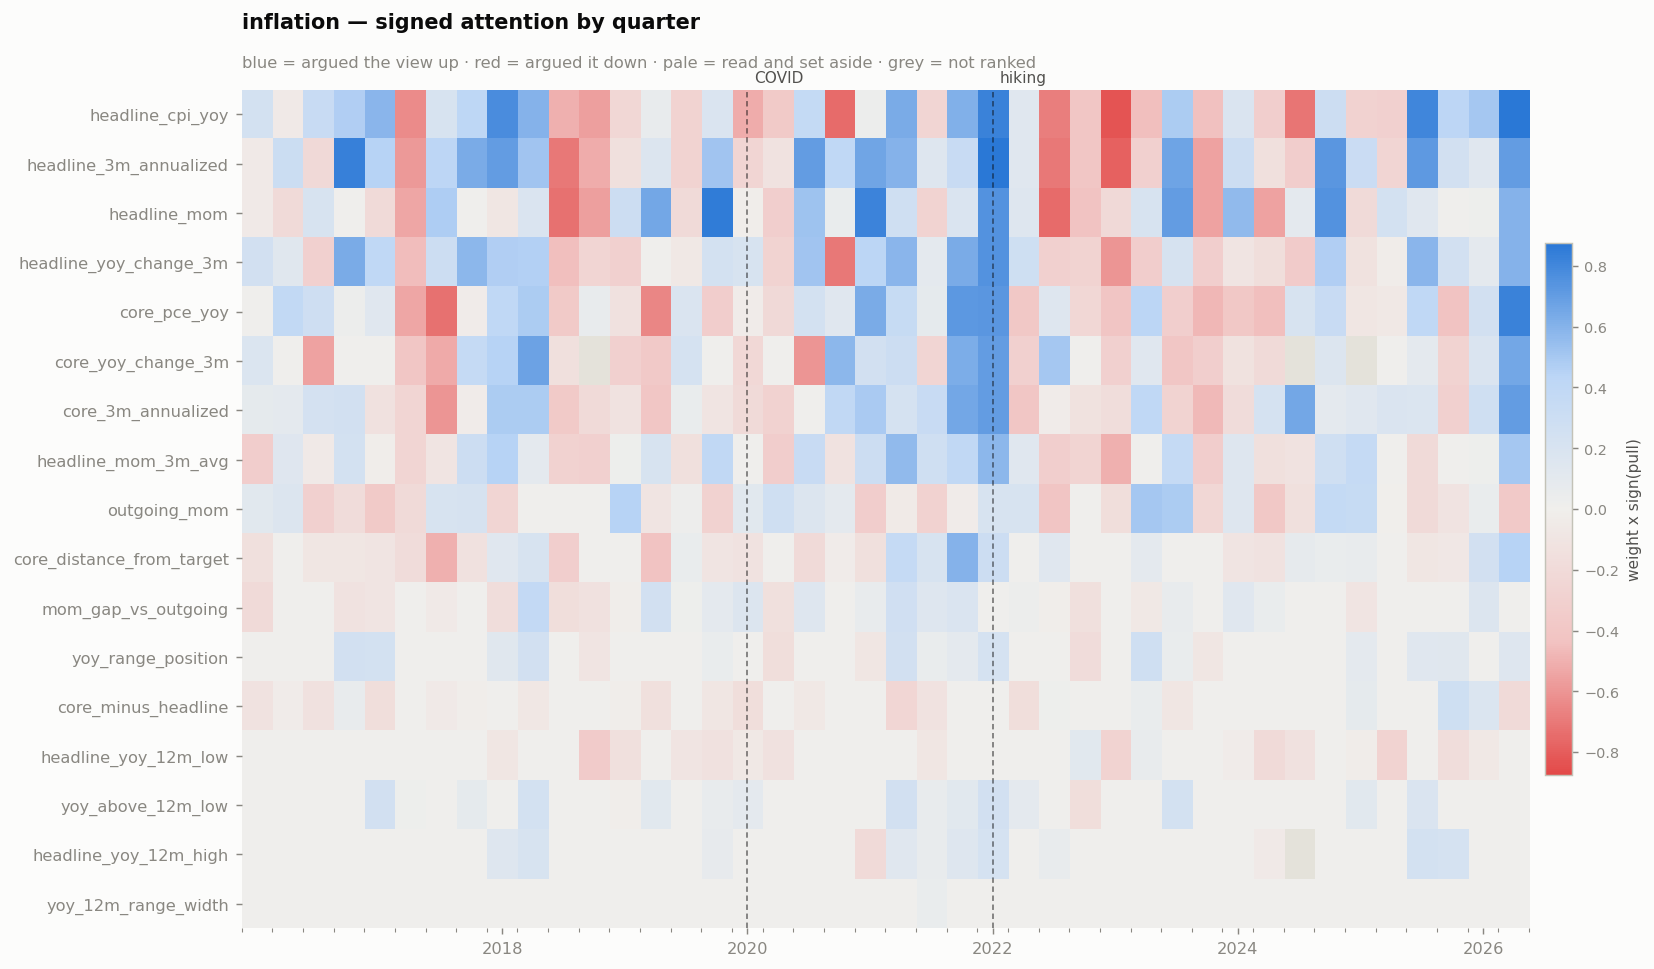

In [4]:
for drv in ["balance_sheet", "inflation"]:
    sp = A.signed_panel(runs[(drv, ARM)])
    if sp.empty: continue
    Q = V.quarterly(sp)
    Q = Q.reindex(Q.abs().mean().sort_values(ascending=False).index, axis=1).T
    fig, ax = plt.subplots(figsize=(13.2, 0.34*len(Q) + 2.6))
    im = V.heat(ax, Q, diverging=True)
    V.mark_regimes(ax, Q.columns)
    cb = fig.colorbar(im, ax=ax, pad=.012, fraction=.02)
    cb.set_label("weight x sign(pull)", fontsize=8.5); cb.ax.tick_params(labelsize=8)
    V.title(ax, f"{drv} — signed attention by quarter",
            "blue = argued the view up · red = argued it down · pale = read and set aside · "
            "grey = not ranked")
    plt.show()

## 4 — Rigid or responsive?

Two numbers per analyst, and the pair is what classifies it.

**Concentration** is a Herfindahl index over the weights, normalised to sum 1 first — so it
measures *spread of attention*, not total conviction. `1/k` means all `k` inputs mattered
equally; near 1 means one input carried the view.

**Turnover** is the share of consecutive meetings where the top-ranked input changed.

Low concentration + low turnover is a genuinely diversified stable process. High concentration
+ high turnover is an analyst that bets heavily on one thing and keeps changing which thing —
the profile most likely to be fitting noise, and invisible to an IC.

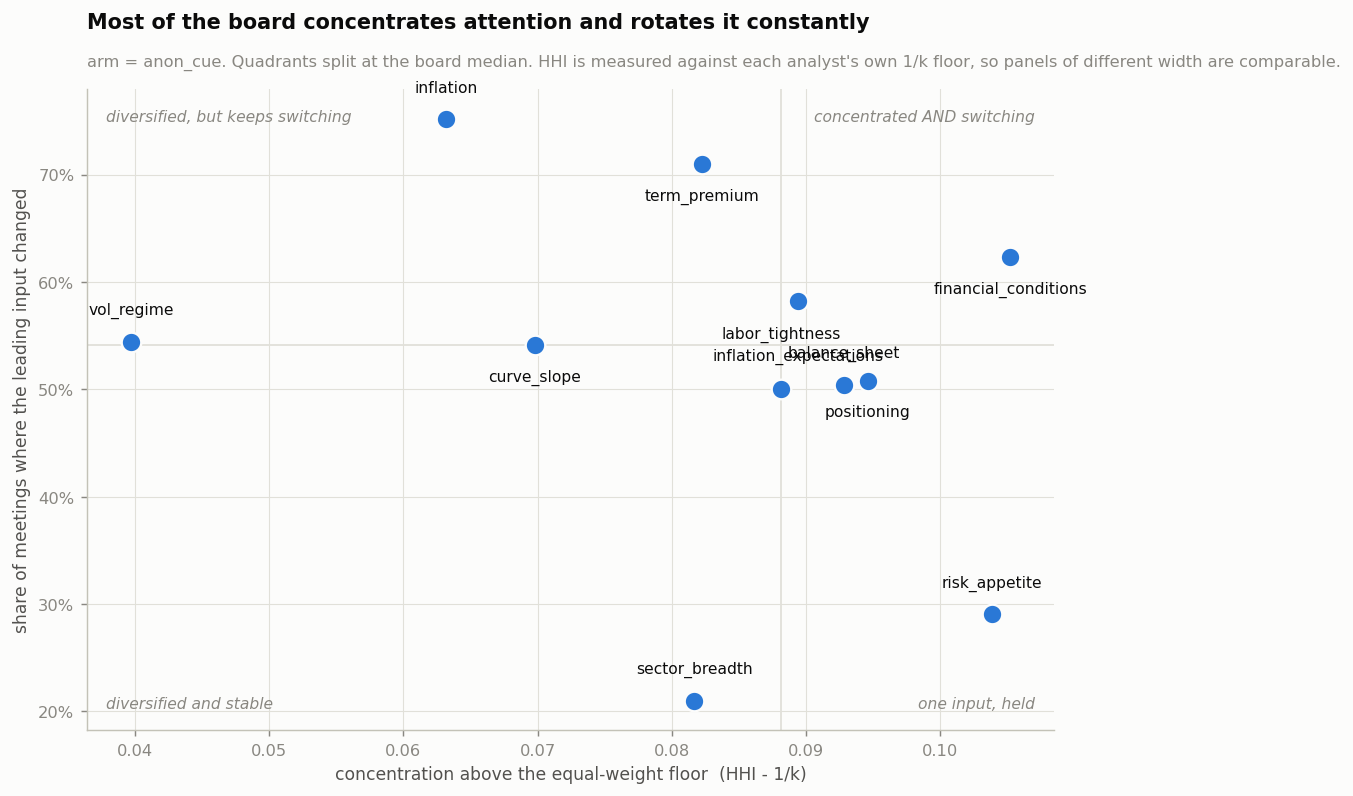

'                driver   hhi  floor  excess  turnover  n_inputs  faithful\n  financial_conditions 0.205  0.100   0.105     0.623        10     0.984\n         risk_appetite 0.437  0.333   0.104     0.290         3     0.945\n           positioning 0.345  0.250   0.095     0.508         4     0.972\n         balance_sheet 0.218  0.125   0.093     0.504         8     1.000\ninflation_expectations 0.189  0.100   0.089     0.582        10     0.977\n       labor_tightness 0.171  0.083   0.088     0.500        12     0.878\n          term_premium 0.173  0.091   0.082     0.710        11     0.976\n        sector_breadth 0.415  0.333   0.082     0.210         3     0.967\n           curve_slope 0.129  0.059   0.070     0.541        17     0.953\n             inflation 0.122  0.059   0.063     0.752        17     0.958\n            vol_regime 0.373  0.333   0.040     0.544         3     0.987'

In [5]:
prof = []
for d in DRIVERS:
    r = runs[(d, ARM)]
    hhi, ti = A.concentration(r), A.top_input(r)
    if hhi.empty or ti.empty: continue
    k = A.weight_panel(r).shape[1]
    turn = float((ti["top_input"] != ti["top_input"].shift()).iloc[1:].mean())
    ag = ti["agrees"].dropna()
    prof.append({"driver": d, "hhi": float(hhi.mean()), "floor": 1.0/k,
                 "excess": float(hhi.mean()) - 1.0/k, "turnover": turn,
                 "n_inputs": k, "faithful": float(ag.mean()) if len(ag) else np.nan})
P = pd.DataFrame(prof)

fig, ax = plt.subplots(figsize=(9.6, 6.4))
ax.scatter(P["excess"], P["turnover"], s=118, color=V.POS, zorder=4,
           edgecolor=V.SURFACE, linewidth=1.3)
V.repel(ax, P["excess"].values, P["turnover"].values, list(P["driver"]))
mx, my = P["excess"].median(), P["turnover"].median()
ax.axvline(mx, color=V.GRID, lw=1.0, zorder=1); ax.axhline(my, color=V.GRID, lw=1.0, zorder=1)
for xf, yf, lab, ha, va in ((.02,.97,"diversified, but keeps switching","left","top"),
                            (.98,.97,"concentrated AND switching","right","top"),
                            (.02,.03,"diversified and stable","left","bottom"),
                            (.98,.03,"one input, held","right","bottom")):
    ax.annotate(lab, xy=(xf,yf), xycoords="axes fraction", ha=ha, va=va,
                fontsize=8.6, color=V.MUTED, style="italic")
ax.set_xlabel("concentration above the equal-weight floor  (HHI - 1/k)")
ax.set_ylabel("share of meetings where the leading input changed")
ax.yaxis.set_major_formatter(lambda v, p: f"{v:.0%}")
V.title(ax, "Most of the board concentrates attention and rotates it constantly",
        f"arm = {ARM}. Quadrants split at the board median. HHI is measured against each "
        f"analyst's own 1/k floor, so panels of different width are comparable.")
V.grid(ax); plt.show()
display(P.sort_values("excess", ascending=False).round(3).to_string(index=False))

## 5 — Does the attribution agree with the call?

The faithfulness check the field exists to enable: does the input the analyst says mattered
most push the same way it actually called?

This is not a skill measure — an analyst can be faithful and wrong, and that is fine. It is an
**internal-consistency** measure. A run where this is often False is one where the stated
reasoning and the stated conclusion disagree, which is worse than either being wrong alone,
because it means the attribution cannot be used to interpret the call at all.

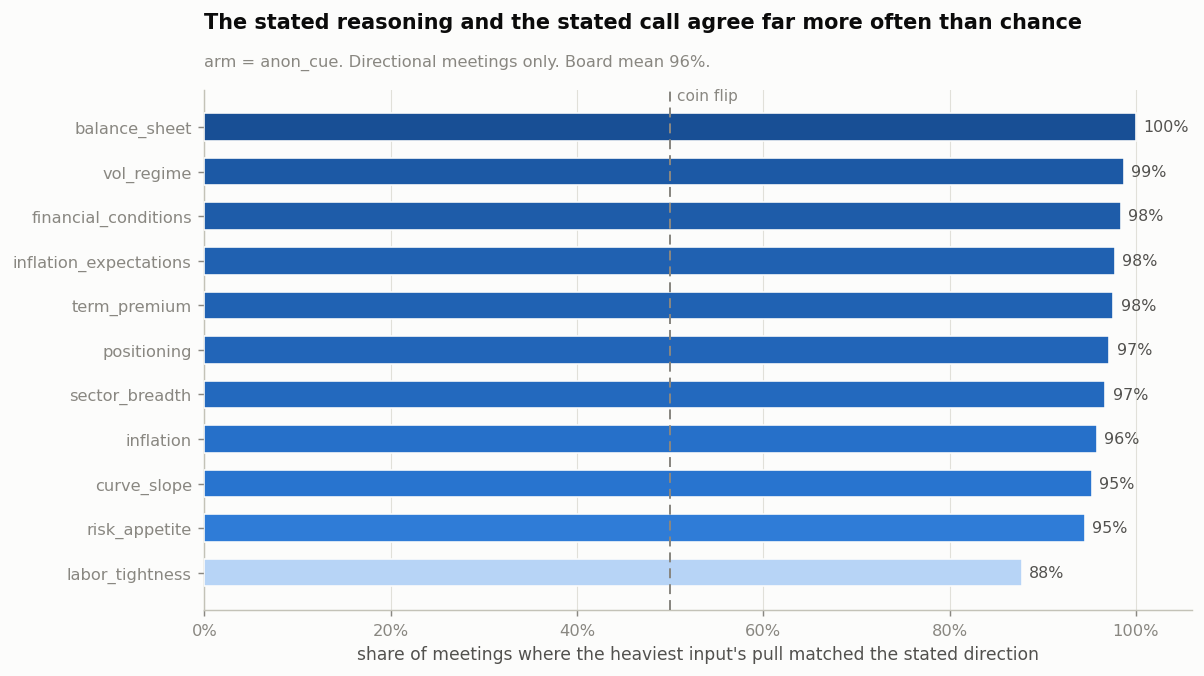

In [6]:
F = P.dropna(subset=["faithful"]).sort_values("faithful")
fig, ax = plt.subplots(figsize=(9.8, 5.2))
y = np.arange(len(F))
ax.barh(y, F["faithful"], color=V.seq_colors(F["faithful"].values), height=.62,
        zorder=3, edgecolor=V.SURFACE, linewidth=.9)
for yi, v in zip(y, F["faithful"]):
    ax.text(v + .008, yi, f"{v:.0%}", va="center", fontsize=8.8, color=V.INK2)
ax.axvline(.5, color=V.MUTED, lw=1.1, ls=(0,(5,3)), zorder=4)
ax.annotate("coin flip", xy=(.5, len(F)-.4), xytext=(4,0), textcoords="offset points",
            fontsize=8.5, color=V.MUTED)
ax.set_yticks(y); ax.set_yticklabels(F["driver"])
ax.set_xlim(0, 1.06); ax.xaxis.set_major_formatter(lambda v,p: f"{v:.0%}")
ax.set_xlabel("share of meetings where the heaviest input's pull matched the stated direction")
V.title(ax, "The stated reasoning and the stated call agree far more often than chance",
        f"arm = {ARM}. Directional meetings only. Board mean {F['faithful'].mean():.0%}.")
V.grid(ax, "x"); plt.show()

## 6 — Does attention move when the world does?

Mean weight per input in three subperiods, split on the same breaks
`ic_diagnostics.regime_ic` uses — so an attention shift and a skill shift can be read against
one timeline. A driver whose IC collapsed in a regime **and** whose attention rotated is a
different story from one that rotated and held.

Sequential ramp, not diverging: this is mean weight, a magnitude with a true zero and no
meaningful midpoint. The first pass put a diverging scale here and every cell landed on the
pale midtone, which is what a diverging scale does to a variable that never goes negative.

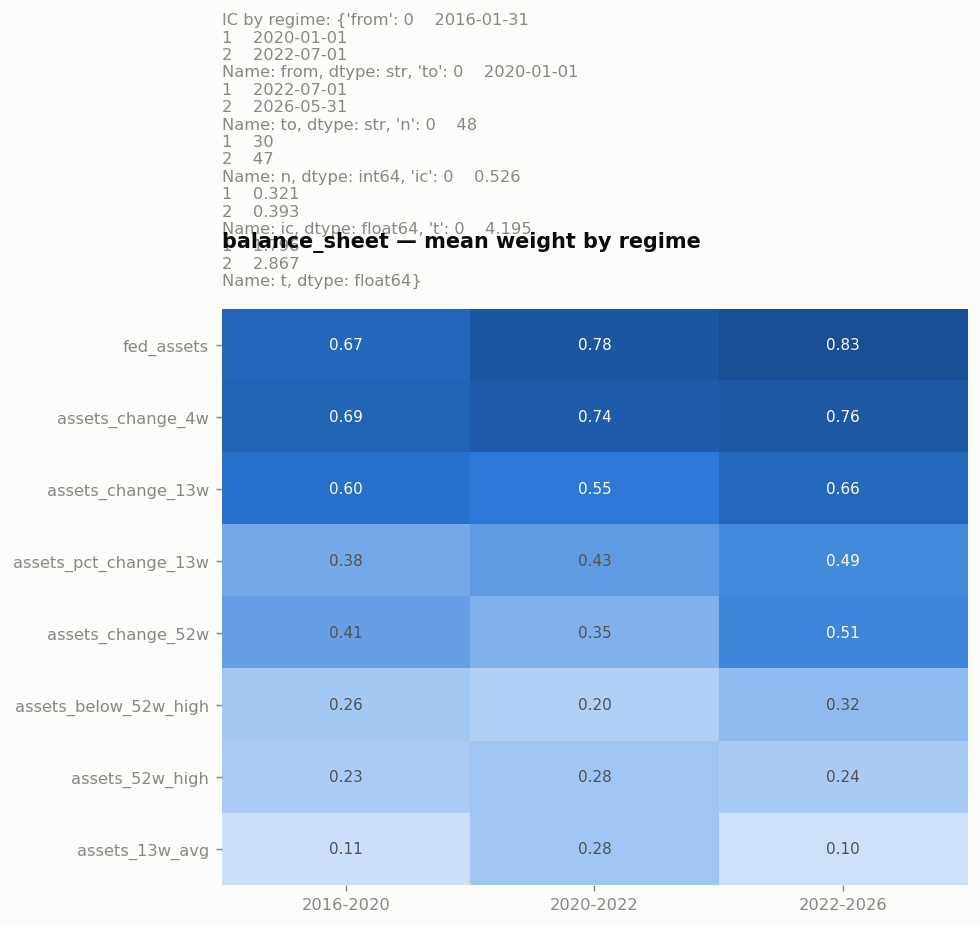

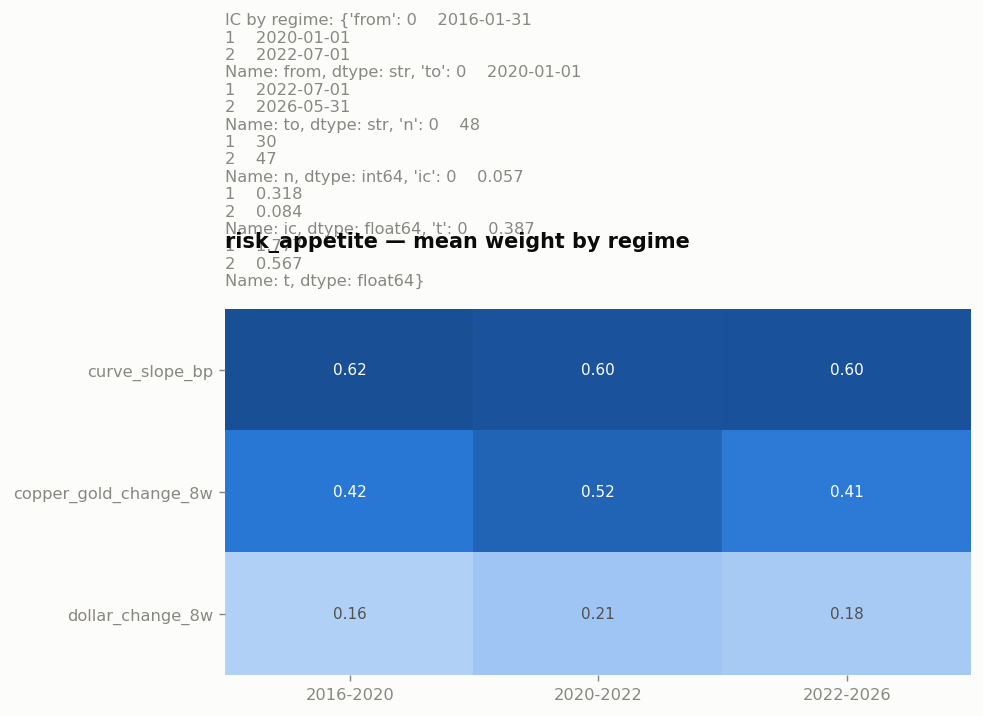

In [7]:
for drv in ["balance_sheet", "risk_appetite"]:
    R = A.regime_attention(runs[(drv, ARM)])
    if R.empty: continue
    R = R.head(10)
    fig, ax = plt.subplots(figsize=(7.4, 0.42*len(R) + 2.4))
    im = ax.imshow(R.values, cmap=V.SEQ, aspect="auto", vmin=0,
                   vmax=float(np.nanmax(R.values)))
    ax.set_xticks(range(R.shape[1])); ax.set_xticklabels(R.columns)
    ax.set_yticks(range(len(R))); ax.set_yticklabels(R.index)
    thr = float(np.nanmax(R.values)) * .55
    for i in range(R.shape[0]):
        for j in range(R.shape[1]):
            v = R.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8.4,
                        color="white" if v > thr else V.INK2)
    for sp in ax.spines.values(): sp.set_visible(False)
    ic = {k: round(v, 3) for k, v in
          D.regime_ic(runs[(drv,ARM)].signed.dropna(),
                      runs[(drv,ARM)].level.dropna()).items()}
    V.title(ax, f"{drv} — mean weight by regime", f"IC by regime: {ic}")
    plt.show()

## 7 — Is the leading input stable, or does its pull flip?

`flip_rate` is the share of consecutive *directional* meetings where an input's pull reversed
sign. Read it **against** mean weight, because the two combine into very different problems:

- **light input, flips often** — a minor consideration the analyst is inconsistent about. Noise
  in a corner of the panel; largely harmless.
- **heavy input, flips often** — the measurement carrying the view is unstable. That is the one
  worth chasing, and it is invisible in any mean-weight table.

Sorted by weight × flip-rate, so the top of the list is exactly the second case.

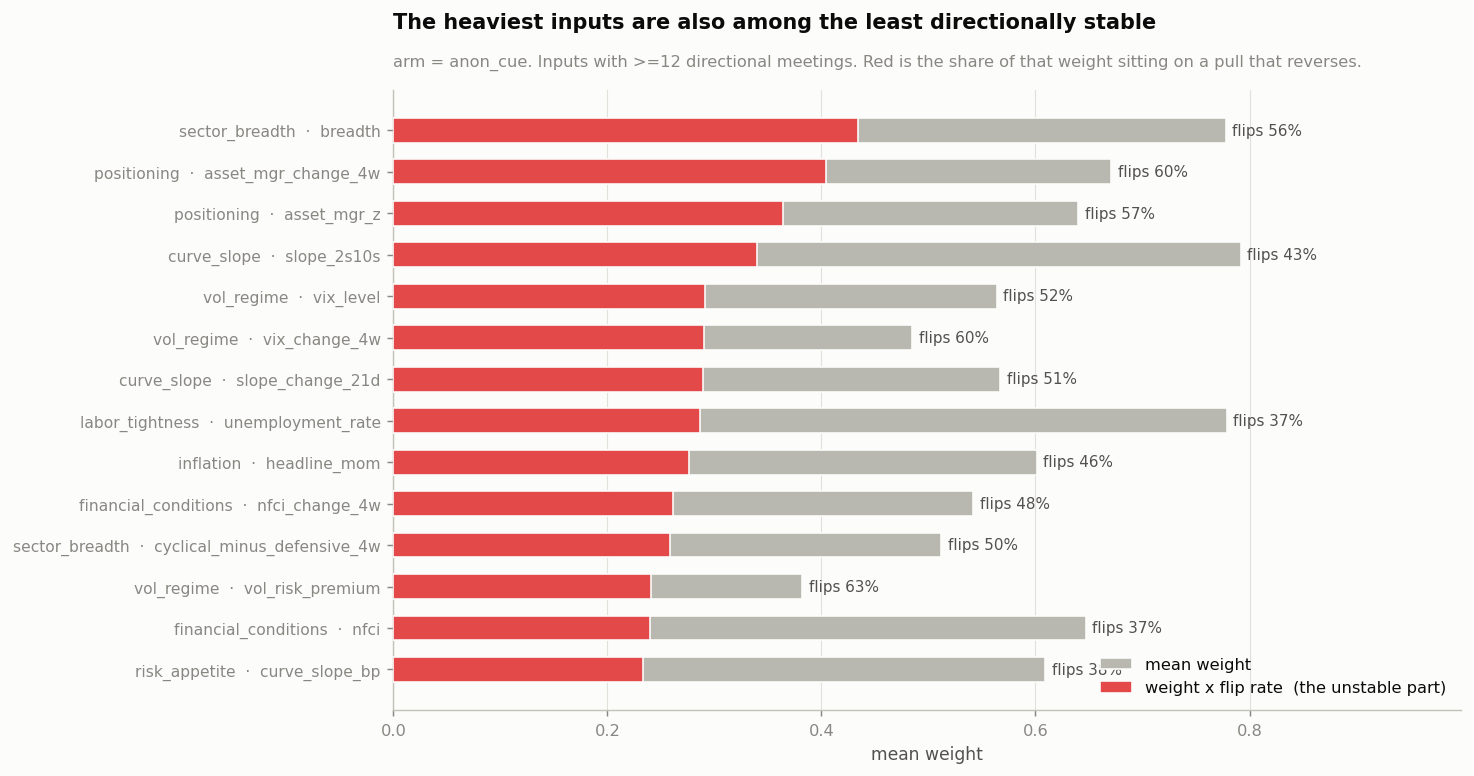

In [8]:
fl = []
for d in DRIVERS:
    f = A.pull_flips(runs[(d, ARM)])
    if f.empty: continue
    fl.append(f.assign(driver=d))
FL = pd.concat(fl)
FL = FL[FL["n_directional"] >= 12].copy()
FL["risk"] = FL["mean_weight"] * FL["flip_rate"]
top = FL.nlargest(14, "risk").iloc[::-1]

fig, ax = plt.subplots(figsize=(10.6, 6.2))
y = np.arange(len(top))
ax.barh(y, top["mean_weight"], color=V.OTHER, height=.6, zorder=3,
        label="mean weight", edgecolor=V.SURFACE, linewidth=.9)
ax.barh(y, top["mean_weight"] * top["flip_rate"], color=V.NEG, height=.6, zorder=4,
        label="weight x flip rate  (the unstable part)", edgecolor=V.SURFACE, linewidth=.9)
for yi, r_ in zip(y, top.itertuples()):
    ax.text(r_.mean_weight + .006, yi, f"flips {r_.flip_rate:.0%}", va="center",
            fontsize=8.4, color=V.INK2)
ax.set_yticks(y)
ax.set_yticklabels([f"{r.driver}  ·  {r.input}" for r in top.itertuples()], fontsize=8.6)
ax.set_xlim(0, float(top["mean_weight"].max()) * 1.26)
ax.set_xlabel("mean weight"); ax.legend(loc="lower right")
V.title(ax, "The heaviest inputs are also among the least directionally stable",
        f"arm = {ARM}. Inputs with >=12 directional meetings. Red is the share of that "
        f"weight sitting on a pull that reverses.")
V.grid(ax, "x"); plt.show()

## 8 — Does giving an analyst text change what it leans on?

The direct question for the four-arm design. If the numeric inputs are ranked the same way
with and without a statement in the context, the text is not displacing the features — it is
either adding nothing or entering somewhere the ranking does not see.

Spearman correlation between the mean-weight vectors of two arms, per analyst. High means the
attention profile survived the text; low means it reorganised.

`positioning` is the built-in control: its `anon_cue` context **is** its `none` context,
because FOMC statements say nothing about CFTC futures positioning and its excerpt coverage is
0%. It should read ~1.00, and if it does not, the comparison is broken rather than
interesting.

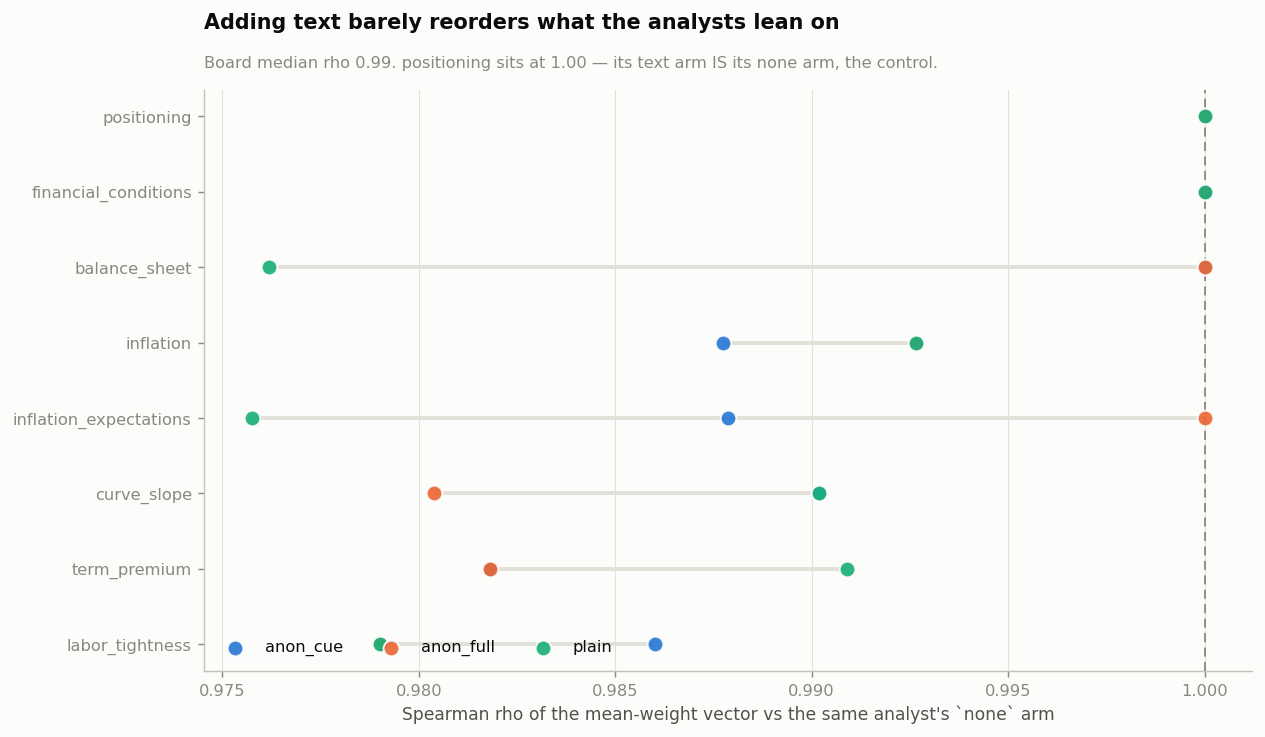

arm                     anon_cue  anon_full  plain
driver                                            
labor_tightness            0.986      0.979  0.979
term_premium               0.982      0.982  0.991
curve_slope                0.990      0.980  0.990
inflation_expectations     0.988      1.000  0.976
inflation                  0.988      0.993  0.993
balance_sheet              1.000      1.000  0.976
financial_conditions       1.000      1.000  1.000
positioning                1.000      1.000  1.000


In [9]:
def profile(d, a):
    s = A.attention_summary(runs[(d, a)])
    return s.set_index("input")["mean_weight"] if not s.empty else pd.Series(dtype=float)

rows = []
for d in DRIVERS:
    base = profile(d, "none")
    if base.empty: continue
    for a in ["anon_cue", "anon_full", "plain"]:
        o = profile(d, a)
        j = pd.concat([base, o], axis=1, keys=["none", a]).dropna()
        if len(j) < 4: continue
        rows.append({"driver": d, "arm": a,
                     "rho": float(j["none"].corr(j[a], method="spearman")),
                     "n_inputs": len(j)})
S = pd.DataFrame(rows).pivot_table(index="driver", columns="arm", values="rho")
S = S.reindex(S.mean(axis=1).sort_values().index)

fig, ax = plt.subplots(figsize=(10.4, 5.8))
y = np.arange(len(S))
cols = {"anon_cue": V.CAT[0], "anon_full": V.CAT[1], "plain": V.CAT[2]}
for a, c in cols.items():
    if a in S: ax.scatter(S[a], y, s=76, color=c, label=a, zorder=4,
                          edgecolor=V.SURFACE, linewidth=1.1, alpha=.92)
ax.hlines(y, S.min(axis=1), S.max(axis=1), color=V.GRID, lw=2.2, zorder=2)
ax.set_yticks(y); ax.set_yticklabels(S.index)
ax.axvline(1.0, color=V.MUTED, lw=1.0, ls=(0,(5,3)), zorder=3)
ax.annotate("identical profile", xy=(1.0, -.6), xytext=(-4,0), textcoords="offset points",
            ha="right", fontsize=8.5, color=V.MUTED)
ax.set_xlabel("Spearman rho of the mean-weight vector vs the same analyst's `none` arm")
ax.legend(loc="lower left", ncols=3)
V.title(ax, "Adding text barely reorders what the analysts lean on",
        f"Board median rho {S.stack().median():.2f}. positioning sits at "
        f"{S.loc['positioning'].mean():.2f} — its text arm IS its none arm, the control.")
V.grid(ax, "x"); plt.show()
print(S.round(3).to_string())

## What this does and does not establish

**Does.** The ranking is populated, complete, and discriminating — explicit zeros throughout,
and the heaviest input agrees with the stated call far more often than chance. The WHICH and
WHEN answers genuinely differ, so both are worth reporting. Attention rotates a great deal
while the weight vector stays nearly flat, and adding text barely reorders it.

**Does not.** A weight is the analyst's **self-report**, not a measured sensitivity. Nothing
here shows that perturbing a high-weight input would move the view — that is what the
perturbation harness is for, and it is the natural follow-up. Treat this as *what the analyst
says it used*, and keep the two claims apart.

**Caveats.**

- Coverage is not uniform. Any mean over a leg in the low-coverage table is noisy, and
  `positioning`'s `anon_cue` is byte-identical to its `none` arm by design.
- Weight 0 and NaN are different and are kept apart everywhere: 0 is "read and set aside",
  NaN is "not in the list". Collapsing them would turn a contract violation into an opinion.
- Flip rates are computed on directional meetings only, so an input that is usually neutral
  can show a high rate off a small denominator — `n_directional` is filtered at 12 for that
  reason and is worth checking before quoting any single row.